In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install -q patool sktime scikit-base --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.5/37.5 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 17.0 MB/s eta 0:00:00


In [3]:
from pathlib import Path
import sys
import os
import glob
import json
import shutil
import random

import numpy as np
import pandas as pd

import torch

In [4]:
PROJECT_DIR = Path(
    "/content/drive/MyDrive/BIL401_Regime_Head_Pruning"
)

REGIME_DIR = PROJECT_DIR / "regime_detection"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
HEAD_IMPORTANCE_DIR = PROJECT_DIR / "head_importance"

HEAD_IMPORTANCE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("REGIME_DIR:", REGIME_DIR)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)
print("HEAD_IMPORTANCE_DIR:", HEAD_IMPORTANCE_DIR)

PROJECT_DIR: /content/drive/MyDrive/BIL401_Regime_Head_Pruning
REGIME_DIR: /content/drive/MyDrive/BIL401_Regime_Head_Pruning/regime_detection
CHECKPOINT_DIR: /content/drive/MyDrive/BIL401_Regime_Head_Pruning/checkpoints
HEAD_IMPORTANCE_DIR: /content/drive/MyDrive/BIL401_Regime_Head_Pruning/head_importance


In [5]:
regime_path = REGIME_DIR / "etth1_validation_regimes_ot_seq336.csv"

regime_df = pd.read_csv(regime_path)

print("Regime df shape:", regime_df.shape)
display(regime_df.head())

print("\nRegime distribution:")
display(regime_df["regime"].value_counts())

Regime df shape: (2785, 13)


,window_id,start_idx,end_idx,input_start_date,input_end_date,trend_score,seasonal_score,residual_score,regime,top_score,second_score,confidence_margin,is_confident
0,0,0,336,2017-06-12 00:00:00,2017-06-25 23:00:00,0.700476,0.205640,0.093884,trend,0.700476,0.205640,0.494836,True
1,1,1,337,2017-06-12 01:00:00,2017-06-26 00:00:00,0.700166,0.206039,0.093796,trend,0.700166,0.206039,0.494127,True
2,2,2,338,2017-06-12 02:00:00,2017-06-26 01:00:00,0.696768,0.208689,0.094543,trend,0.696768,0.208689,0.488079,True
3,3,3,339,2017-06-12 03:00:00,2017-06-26 02:00:00,0.689886,0.213555,0.096559,trend,0.689886,0.213555,0.476330,True
4,4,4,340,2017-06-12 04:00:00,2017-06-26 03:00:00,0.677356,0.223502,0.099142,trend,0.677356,0.223502,0.453854,True



Regime distribution:


,count
regime,
trend,2134
residual,359
seasonal,292


In [6]:
confident_regime_path = (
    REGIME_DIR
    / "etth1_validation_regimes_confident_seq336.csv"
)

confident_regime_df = pd.read_csv(confident_regime_path)

print("Confident regime df shape:", confident_regime_df.shape)
display(confident_regime_df.head())

print("\nConfident regime distribution:")
display(confident_regime_df["regime"].value_counts())

Confident regime df shape: (2490, 13)


,window_id,start_idx,end_idx,input_start_date,input_end_date,trend_score,seasonal_score,residual_score,regime,top_score,second_score,confidence_margin,is_confident
0,0,0,336,2017-06-12 00:00:00,2017-06-25 23:00:00,0.700476,0.205640,0.093884,trend,0.700476,0.205640,0.494836,True
1,1,1,337,2017-06-12 01:00:00,2017-06-26 00:00:00,0.700166,0.206039,0.093796,trend,0.700166,0.206039,0.494127,True
2,2,2,338,2017-06-12 02:00:00,2017-06-26 01:00:00,0.696768,0.208689,0.094543,trend,0.696768,0.208689,0.488079,True
3,3,3,339,2017-06-12 03:00:00,2017-06-26 02:00:00,0.689886,0.213555,0.096559,trend,0.689886,0.213555,0.476330,True
4,4,4,340,2017-06-12 04:00:00,2017-06-26 03:00:00,0.677356,0.223502,0.099142,trend,0.677356,0.223502,0.453854,True



Confident regime distribution:


,count
regime,
trend,1940
residual,287
seasonal,263


In [7]:
TSLIB_DIR = Path("/content/Time-Series-Library")

if not TSLIB_DIR.exists():
    %cd /content
    !git clone https://github.com/thuml/Time-Series-Library.git
else:
    print("Time-Series-Library already exists:", TSLIB_DIR)

/content
Cloning into 'Time-Series-Library'...
remote: Enumerating objects: 2295, done.
remote: Total 2295 (delta 0), reused 0 (delta 0), pack-reused 2295 (from 1)
Receiving objects: 100% (2295/2295), 78.43 MiB | 20.77 MiB/s, done.
Resolving deltas: 100% (1570/1570), done.


In [8]:
sys.path.insert(0, str(TSLIB_DIR))

print(sys.path[0])

/content/Time-Series-Library


In [9]:
drive_data_path = PROJECT_DIR / "data" / "ETTh1.csv"

tslib_data_path = (
    TSLIB_DIR
    / "dataset/ETDataset/ETT-small/ETTh1.csv"
)

tslib_data_path.parent.mkdir(parents=True, exist_ok=True)

if drive_data_path.exists():
    shutil.copy2(drive_data_path, tslib_data_path)
    print("ETTh1 copied from Drive.")
else:
    print("Drive data not found. Downloading ETTh1...")
    !wget -q https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv -O /content/Time-Series-Library/dataset/ETDataset/ETT-small/ETTh1.csv

print("Dataset exists:", tslib_data_path.exists())
print("Dataset path:", tslib_data_path)

Drive data not found. Downloading ETTh1...
Dataset exists: True
Dataset path: /content/Time-Series-Library/dataset/ETDataset/ETT-small/ETTh1.csv


In [10]:
df = pd.read_csv(tslib_data_path)

print(df.shape)
print(df.columns.tolist())
display(df.head())

(17420, 8)
['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [11]:
b4_checkpoint_candidates = list(
    CHECKPOINT_DIR.glob(
        "B4_patchtst_etth1_336_dm128_h8/**/checkpoint.pth"
    )
)

print("Found checkpoint candidates:")

for path in b4_checkpoint_candidates:
    print(path)

if len(b4_checkpoint_candidates) == 0:
    raise FileNotFoundError(
        "B4 checkpoint bulunamadı. CHECKPOINT_DIR içini kontrol et."
    )

b4_checkpoint_path = b4_checkpoint_candidates[0]

print("\nSelected checkpoint:")
print(b4_checkpoint_path)

Found checkpoint candidates:
/content/drive/MyDrive/BIL401_Regime_Head_Pruning/checkpoints/B4_patchtst_etth1_336_dm128_h8/checkpoint.pth

Selected checkpoint:
/content/drive/MyDrive/BIL401_Regime_Head_Pruning/checkpoints/B4_patchtst_etth1_336_dm128_h8/checkpoint.pth


In [15]:
from argparse import Namespace

args = Namespace(
    # task
    task_name="long_term_forecast",
    is_training=0,
    model_id="ETTh1_336_96_dm128_h8",
    model="PatchTST",

    # data
    data="ETTh1",
    root_path="./dataset/ETDataset/ETT-small/",
    data_path="ETTh1.csv",
    features="M",
    target="OT",
    freq="h",
    checkpoints="./checkpoints/",

    # forecasting
    seq_len=336,
    label_len=48,
    pred_len=96,
    seasonal_patterns="Monthly",
    inverse=False,

    # model
    enc_in=7,
    dec_in=7,
    c_out=7,
    d_model=128,
    n_heads=8,
    e_layers=3,
    d_layers=1,
    d_ff=256,
    moving_avg=25,
    factor=3,
    distil=True,
    dropout=0.1,
    embed="timeF",
    activation="gelu",
    output_attention=False,

    # PatchTST related
    patch_len=16,
    stride=8,
    padding_patch="end",
    revin=1,
    affine=0,
    subtract_last=0,
    decomposition=0,
    kernel_size=25,
    individual=0,

    # optimization / loader
    num_workers=2,
    itr=1,
    train_epochs=10,
    batch_size=32,
    patience=3,
    learning_rate=0.0001,
    des="baseline_b4",
    loss="MSE",
    lradj="type1",
    use_amp=False,

    # GPU
    use_gpu=torch.cuda.is_available(),
    gpu=0,
    use_multi_gpu=False,
    devices="0",
    gpu_type="cuda", # Added gpu_type attribute

    # other model families, required by some imports
    expand=2,
    d_conv=4,
    top_k=5,
    num_kernels=6,
    channel_independence=0,
    decomp_method="moving_avg",
    use_norm=1,
    down_sampling_layers=0,
    down_sampling_window=1,
    down_sampling_method=None,
    seg_len=48,

    # MLP projection args sometimes expected
    p_hidden_dims=[128, 128],
    p_hidden_layers=2,
)

print(args)

Namespace(task_name='long_term_forecast', is_training=0, model_id='ETTh1_336_96_dm128_h8', model='PatchTST', data='ETTh1', root_path='./dataset/ETDataset/ETT-small/', data_path='ETTh1.csv', features='M', target='OT', freq='h', checkpoints='./checkpoints/', seq_len=336, label_len=48, pred_len=96, seasonal_patterns='Monthly', inverse=False, enc_in=7, dec_in=7, c_out=7, d_model=128, n_heads=8, e_layers=3, d_layers=1, d_ff=256, moving_avg=25, factor=3, distil=True, dropout=0.1, embed='timeF', activation='gelu', output_attention=False, patch_len=16, stride=8, padding_patch='end', revin=1, affine=0, subtract_last=0, decomposition=0, kernel_size=25, individual=0, num_workers=2, itr=1, train_epochs=10, batch_size=32, patience=3, learning_rate=0.0001, des='baseline_b4', loss='MSE', lradj='type1', use_amp=False, use_gpu=True, gpu=0, use_multi_gpu=False, devices='0', gpu_type='cuda', expand=2, d_conv=4, top_k=5, num_kernels=6, channel_independence=0, decomp_method='moving_avg', use_norm=1, down_s

In [13]:
%cd /content/Time-Series-Library

/content/Time-Series-Library


In [17]:
!pip install reformer-pytorch --no-deps

In [19]:
!pip install local-attention --no-deps

In [21]:
!pip install hyper_connections --no-deps

In [23]:
!pip install axial_positional_embedding --no-deps

In [25]:
!pip install product_key_memory --no-deps

In [27]:
!pip install colt5_attention --no-deps

In [29]:
from exp.exp_long_term_forecasting import Exp_Long_Term_Forecast

exp = Exp_Long_Term_Forecast(args)
model = exp.model

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

checkpoint = torch.load(
    b4_checkpoint_path,
    map_location=device,
)

model.load_state_dict(checkpoint)

model.eval()

print("Model loaded successfully.")
print("Device:", device)

Use GPU: cuda:0
🚀 Lazy Loading: PatchTST ...
Model loaded successfully.
Device: cuda:0


In [30]:
from data_provider.data_factory import data_provider

vali_data, vali_loader = data_provider(
    args,
    flag="val",
)

print("Validation dataset length:", len(vali_data))
print("Validation loader batches:", len(vali_loader))

val 2785
Validation dataset length: 2785
Validation loader batches: 88


In [31]:
assert len(vali_data) == len(regime_df), (
    len(vali_data),
    len(regime_df),
)

print("Validation windows and regime labels match.")

Validation windows and regime labels match.


In [32]:
batch = next(iter(vali_loader))

for i, item in enumerate(batch):
    print(i, type(item), item.shape if hasattr(item, "shape") else None)

0 <class 'torch.Tensor'> torch.Size([32, 336, 7])
1 <class 'torch.Tensor'> torch.Size([32, 144, 7])
2 <class 'torch.Tensor'> torch.Size([32, 336, 4])
3 <class 'torch.Tensor'> torch.Size([32, 144, 4])


In [33]:
batch_x, batch_y, batch_x_mark, batch_y_mark = batch

batch_x = batch_x.float().to(device)
batch_y = batch_y.float().to(device)
batch_x_mark = batch_x_mark.float().to(device)
batch_y_mark = batch_y_mark.float().to(device)

with torch.no_grad():
    outputs = model(
        batch_x,
        batch_x_mark,
        batch_y,
        batch_y_mark,
    )

print("Output shape:", outputs.shape)
print("Target shape:", batch_y.shape)

Output shape: torch.Size([32, 96, 7])
Target shape: torch.Size([32, 144, 7])


In [34]:
for name, module in model.named_modules():
    class_name = module.__class__.__name__

    if (
        "Attention" in class_name
        or "attention" in class_name
        or "Attn" in class_name
        or "attn" in name.lower()
    ):
        print(name, "->", class_name)

encoder.attn_layers -> ModuleList
encoder.attn_layers.0 -> EncoderLayer
encoder.attn_layers.0.attention -> AttentionLayer
encoder.attn_layers.0.attention.inner_attention -> FullAttention
encoder.attn_layers.0.attention.inner_attention.dropout -> Dropout
encoder.attn_layers.0.attention.query_projection -> Linear
encoder.attn_layers.0.attention.key_projection -> Linear
encoder.attn_layers.0.attention.value_projection -> Linear
encoder.attn_layers.0.attention.out_projection -> Linear
encoder.attn_layers.0.conv1 -> Conv1d
encoder.attn_layers.0.conv2 -> Conv1d
encoder.attn_layers.0.norm1 -> LayerNorm
encoder.attn_layers.0.norm2 -> LayerNorm
encoder.attn_layers.0.dropout -> Dropout
encoder.attn_layers.1 -> EncoderLayer
encoder.attn_layers.1.attention -> AttentionLayer
encoder.attn_layers.1.attention.inner_attention -> FullAttention
encoder.attn_layers.1.attention.inner_attention.dropout -> Dropout
encoder.attn_layers.1.attention.query_projection -> Linear
encoder.attn_layers.1.attention.key_

In [35]:
candidate_modules = []

for name, module in model.named_modules():
    attrs = dir(module)

    has_n_heads = hasattr(module, "n_heads")
    has_attention = (
        "attention" in name.lower()
        or "attn" in name.lower()
        or "Attention" in module.__class__.__name__
    )

    if has_n_heads or has_attention:
        candidate_modules.append((name, module))

for name, module in candidate_modules:
    print("=" * 80)
    print("Name:", name)
    print("Class:", module.__class__.__name__)

    for attr in ["n_heads", "d_model", "d_keys", "d_values"]:
        if hasattr(module, attr):
            print(attr, "=", getattr(module, attr))

Name: encoder.attn_layers
Class: ModuleList
Name: encoder.attn_layers.0
Class: EncoderLayer
Name: encoder.attn_layers.0.attention
Class: AttentionLayer
n_heads = 8
Name: encoder.attn_layers.0.attention.inner_attention
Class: FullAttention
Name: encoder.attn_layers.0.attention.inner_attention.dropout
Class: Dropout
Name: encoder.attn_layers.0.attention.query_projection
Class: Linear
Name: encoder.attn_layers.0.attention.key_projection
Class: Linear
Name: encoder.attn_layers.0.attention.value_projection
Class: Linear
Name: encoder.attn_layers.0.attention.out_projection
Class: Linear
Name: encoder.attn_layers.0.conv1
Class: Conv1d
Name: encoder.attn_layers.0.conv2
Class: Conv1d
Name: encoder.attn_layers.0.norm1
Class: LayerNorm
Name: encoder.attn_layers.0.norm2
Class: LayerNorm
Name: encoder.attn_layers.0.dropout
Class: Dropout
Name: encoder.attn_layers.1
Class: EncoderLayer
Name: encoder.attn_layers.1.attention
Class: AttentionLayer
n_heads = 8
Name: encoder.attn_layers.1.attention.inner

In [36]:
for name, param in model.named_parameters():
    if (
        "attn" in name.lower()
        or "attention" in name.lower()
        or "query" in name.lower()
        or "key" in name.lower()
        or "value" in name.lower()
        or "projection" in name.lower()
    ):
        print(name, tuple(param.shape))

patch_embedding.value_embedding.weight (128, 16)
encoder.attn_layers.0.attention.query_projection.weight (128, 128)
encoder.attn_layers.0.attention.query_projection.bias (128,)
encoder.attn_layers.0.attention.key_projection.weight (128, 128)
encoder.attn_layers.0.attention.key_projection.bias (128,)
encoder.attn_layers.0.attention.value_projection.weight (128, 128)
encoder.attn_layers.0.attention.value_projection.bias (128,)
encoder.attn_layers.0.attention.out_projection.weight (128, 128)
encoder.attn_layers.0.attention.out_projection.bias (128,)
encoder.attn_layers.0.conv1.weight (256, 128, 1)
encoder.attn_layers.0.conv1.bias (256,)
encoder.attn_layers.0.conv2.weight (128, 256, 1)
encoder.attn_layers.0.conv2.bias (128,)
encoder.attn_layers.0.norm1.weight (128,)
encoder.attn_layers.0.norm1.bias (128,)
encoder.attn_layers.0.norm2.weight (128,)
encoder.attn_layers.0.norm2.bias (128,)
encoder.attn_layers.1.attention.query_projection.weight (128, 128)
encoder.attn_layers.1.attention.query_

In [37]:
import torch
import torch.nn as nn
from tqdm.auto import tqdm
import pandas as pd
import numpy as np

criterion = nn.MSELoss(reduction="none")

def compute_regime_losses(
    model,
    vali_loader,
    regime_df,
    device,
    pred_len=96,
):
    """
    Validation set üzerinde her örnek için MSE hesaplar.
    Sonra regime bazında ortalama loss döndürür.
    """

    model.eval()

    all_records = []
    global_index = 0

    with torch.no_grad():
        for batch in tqdm(vali_loader, desc="Computing validation losses"):
            batch_x, batch_y, batch_x_mark, batch_y_mark = batch

            batch_x = batch_x.float().to(device)
            batch_y = batch_y.float().to(device)
            batch_x_mark = batch_x_mark.float().to(device)
            batch_y_mark = batch_y_mark.float().to(device)

            outputs = model(
                batch_x,
                batch_x_mark,
                batch_y,
                batch_y_mark,
            )

            true = batch_y[:, -pred_len:, :]

            # [B, pred_len, channels]
            loss_per_element = criterion(outputs, true)

            # Her örnek için ortalama MSE
            # [B]
            loss_per_sample = loss_per_element.mean(dim=(1, 2))

            batch_size = batch_x.shape[0]

            for i in range(batch_size):
                window_id = global_index + i

                regime = regime_df.iloc[window_id]["regime"]

                all_records.append({
                    "window_id": window_id,
                    "regime": regime,
                    "mse": float(loss_per_sample[i].detach().cpu()),
                })

            global_index += batch_size

    loss_df = pd.DataFrame(all_records)

    regime_losses = (
        loss_df
        .groupby("regime")["mse"]
        .mean()
        .to_dict()
    )

    overall_loss = float(loss_df["mse"].mean())

    return {
        "overall_loss": overall_loss,
        "regime_losses": regime_losses,
        "loss_df": loss_df,
    }

In [38]:
baseline_result = compute_regime_losses(
    model=model,
    vali_loader=vali_loader,
    regime_df=regime_df,
    device=device,
    pred_len=args.pred_len,
)

print("Overall validation MSE:", baseline_result["overall_loss"])
print("\nRegime losses:")
for regime, loss in baseline_result["regime_losses"].items():
    print(regime, loss)

baseline_loss_df = baseline_result["loss_df"]
display(baseline_loss_df.head())

Computing validation losses:   0%|          | 0/88 [00:00<?, ?it/s]

Overall validation MSE: 0.6780664091023552

Regime losses:
residual 0.6614194310848759
seasonal 0.7066892384717317
trend 0.6769503823602825


,window_id,regime,mse
0,0,trend,0.765757
1,1,trend,0.327511
2,2,trend,0.262037
3,3,trend,0.330849
4,4,trend,0.571593


In [39]:
baseline_loss_path = (
    HEAD_IMPORTANCE_DIR
    / "b4_baseline_validation_losses_by_window.csv"
)

baseline_loss_df.to_csv(
    baseline_loss_path,
    index=False,
)

baseline_summary = pd.DataFrame([
    {
        "setting": "B4_no_mask",
        "overall_mse": baseline_result["overall_loss"],
        "trend_mse": baseline_result["regime_losses"].get("trend", np.nan),
        "seasonal_mse": baseline_result["regime_losses"].get("seasonal", np.nan),
        "residual_mse": baseline_result["regime_losses"].get("residual", np.nan),
    }
])

baseline_summary_path = (
    HEAD_IMPORTANCE_DIR
    / "b4_baseline_regime_loss_summary.csv"
)

baseline_summary.to_csv(
    baseline_summary_path,
    index=False,
)

display(baseline_summary)

print("Saved:")
print(baseline_loss_path)
print(baseline_summary_path)

,setting,overall_mse,trend_mse,seasonal_mse,residual_mse
0,B4_no_mask,0.678066,0.67695,0.706689,0.661419


Saved:
/content/drive/MyDrive/BIL401_Regime_Head_Pruning/head_importance/b4_baseline_validation_losses_by_window.csv
/content/drive/MyDrive/BIL401_Regime_Head_Pruning/head_importance/b4_baseline_regime_loss_summary.csv


In [40]:
import inspect

attention_layer = model.encoder.attn_layers[0].attention

print(attention_layer)
print(inspect.signature(attention_layer.forward))
print(inspect.getsource(attention_layer.forward))

AttentionLayer(
  (inner_attention): FullAttention(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (query_projection): Linear(in_features=128, out_features=128, bias=True)
  (key_projection): Linear(in_features=128, out_features=128, bias=True)
  (value_projection): Linear(in_features=128, out_features=128, bias=True)
  (out_projection): Linear(in_features=128, out_features=128, bias=True)
)
(queries, keys, values, attn_mask, tau=None, delta=None)
    def forward(self, queries, keys, values, attn_mask, tau=None, delta=None):
        B, L, _ = queries.shape
        _, S, _ = keys.shape
        H = self.n_heads

        queries = self.query_projection(queries).view(B, L, H, -1)
        keys = self.key_projection(keys).view(B, S, H, -1)
        values = self.value_projection(values).view(B, S, H, -1)

        out, attn = self.inner_attention(
            queries,
            keys,
            values,
            attn_mask,
            tau=tau,
            delta=delta
        )
       

In [41]:
class HeadMaskController:
    def __init__(self, model):
        self.model = model
        self.original_forwards = {}
        self.current_mask = None

    def install(self):
        """
        AttentionLayer forward fonksiyonlarını mask destekli hale getirir.
        """

        for layer_idx, encoder_layer in enumerate(self.model.encoder.attn_layers):
            attention_layer = encoder_layer.attention

            if layer_idx in self.original_forwards:
                continue

            self.original_forwards[layer_idx] = attention_layer.forward

            def make_masked_forward(layer_idx, attention_layer):
                original_forward = attention_layer.forward

                def masked_forward(
                    queries,
                    keys,
                    values,
                    attn_mask,
                    tau=None,
                    delta=None,
                ):
                    B, L, _ = queries.shape
                    _, S, _ = keys.shape

                    H = attention_layer.n_heads

                    queries_proj = attention_layer.query_projection(queries)
                    keys_proj = attention_layer.key_projection(keys)
                    values_proj = attention_layer.value_projection(values)

                    queries_proj = queries_proj.view(B, L, H, -1)
                    keys_proj = keys_proj.view(B, S, H, -1)
                    values_proj = values_proj.view(B, S, H, -1)

                    out, attn = attention_layer.inner_attention(
                        queries_proj,
                        keys_proj,
                        values_proj,
                        attn_mask,
                        tau=tau,
                        delta=delta,
                    )

                    # out shape: [B, L, H, D]
                    if self.current_mask is not None:
                        layer_mask = self.current_mask[layer_idx].to(out.device)
                        # [H] -> [1, 1, H, 1]
                        layer_mask = layer_mask.view(1, 1, H, 1)
                        out = out * layer_mask

                    out = out.view(B, L, -1)

                    return attention_layer.out_projection(out), attn

                return masked_forward

            attention_layer.forward = make_masked_forward(
                layer_idx,
                attention_layer,
            )

    def remove(self):
        """
        Orijinal forward fonksiyonlarını geri yükler.
        """

        for layer_idx, original_forward in self.original_forwards.items():
            self.model.encoder.attn_layers[layer_idx].attention.forward = original_forward

        self.original_forwards = {}
        self.current_mask = None

    def set_all_active(self):
        """
        Tüm head'ler açık.
        """

        num_layers = len(self.model.encoder.attn_layers)
        num_heads = self.model.encoder.attn_layers[0].attention.n_heads

        self.current_mask = torch.ones(
            num_layers,
            num_heads,
            dtype=torch.float32,
        )

    def mask_single_head(self, layer_idx, head_idx):
        """
        Sadece verilen head'i kapatır.
        """

        self.set_all_active()
        self.current_mask[layer_idx, head_idx] = 0.0

In [42]:
mask_controller = HeadMaskController(model)
mask_controller.install()

mask_controller.set_all_active()

model.eval()

with torch.no_grad():
    outputs_all_active = model(
        batch_x,
        batch_x_mark,
        batch_y,
        batch_y_mark,
    )

print("All active output shape:", outputs_all_active.shape)

All active output shape: torch.Size([32, 96, 7])


In [43]:
mask_controller.mask_single_head(
    layer_idx=0,
    head_idx=0,
)

with torch.no_grad():
    outputs_masked = model(
        batch_x,
        batch_x_mark,
        batch_y,
        batch_y_mark,
    )

print("Masked output shape:", outputs_masked.shape)

diff = torch.mean(
    torch.abs(outputs_all_active - outputs_masked)
).item()

print("Mean absolute output difference:", diff)

Masked output shape: torch.Size([32, 96, 7])
Mean absolute output difference: 0.02741265669465065


In [44]:
mask_controller.set_all_active()

In [45]:
num_layers = len(model.encoder.attn_layers)
num_heads = model.encoder.attn_layers[0].attention.n_heads

print("Layers:", num_layers)
print("Heads per layer:", num_heads)
print("Total heads:", num_layers * num_heads)

Layers: 3
Heads per layer: 8
Total heads: 24


In [46]:
importance_records = []

baseline_overall = baseline_result["overall_loss"]
baseline_by_regime = baseline_result["regime_losses"]

for layer_idx in range(num_layers):
    for head_idx in range(num_heads):
        print("=" * 80)
        print(f"Masking Layer {layer_idx}, Head {head_idx}")

        mask_controller.mask_single_head(
            layer_idx=layer_idx,
            head_idx=head_idx,
        )

        masked_result = compute_regime_losses(
            model=model,
            vali_loader=vali_loader,
            regime_df=regime_df,
            device=device,
            pred_len=args.pred_len,
        )

        masked_overall = masked_result["overall_loss"]
        masked_by_regime = masked_result["regime_losses"]

        record = {
            "layer": layer_idx,
            "head": head_idx,

            "baseline_overall_mse": baseline_overall,
            "masked_overall_mse": masked_overall,
            "overall_importance": masked_overall - baseline_overall,
        }

        for regime in ["trend", "seasonal", "residual"]:
            baseline_regime_loss = baseline_by_regime.get(regime, np.nan)
            masked_regime_loss = masked_by_regime.get(regime, np.nan)

            record[f"baseline_{regime}_mse"] = baseline_regime_loss
            record[f"masked_{regime}_mse"] = masked_regime_loss
            record[f"{regime}_importance"] = (
                masked_regime_loss - baseline_regime_loss
            )

        importance_records.append(record)

        importance_df_partial = pd.DataFrame(importance_records)

        partial_path = (
            HEAD_IMPORTANCE_DIR
            / "b4_head_importance_partial.csv"
        )

        importance_df_partial.to_csv(
            partial_path,
            index=False,
        )

        display(importance_df_partial.tail(1))

# Tüm head'ler bittikten sonra maskeyi normale al
mask_controller.set_all_active()

importance_df = pd.DataFrame(importance_records)

importance_path = (
    HEAD_IMPORTANCE_DIR
    / "b4_head_importance_all_windows.csv"
)

importance_df.to_csv(
    importance_path,
    index=False,
)

display(importance_df)

print("Head importance dosyası kaydedildi:")
print(importance_path)

Masking Layer 0, Head 0


Computing validation losses:   0%|          | 0/88 [00:00<?, ?it/s]

,layer,head,baseline_overall_mse,masked_overall_mse,overall_importance,baseline_trend_mse,masked_trend_mse,trend_importance,baseline_seasonal_mse,masked_seasonal_mse,seasonal_importance,baseline_residual_mse,masked_residual_mse,residual_importance
0,0,0,0.678066,0.682159,0.004092,0.67695,0.680246,0.003296,0.706689,0.708879,0.00219,0.661419,0.671793,0.010374


Masking Layer 0, Head 1


Computing validation losses:   0%|          | 0/88 [00:00<?, ?it/s]

...

Masking Layer 2, Head 7


Computing validation losses:   0%|          | 0/88 [00:00<?, ?it/s]

,layer,head,baseline_overall_mse,masked_overall_mse,overall_importance,baseline_trend_mse,masked_trend_mse,trend_importance,baseline_seasonal_mse,masked_seasonal_mse,seasonal_importance,baseline_residual_mse,masked_residual_mse,residual_importance
23,2,7,0.678066,0.679316,0.001249,0.67695,0.667901,-0.00905,0.706689,0.716163,0.009473,0.661419,0.717199,0.05578


,layer,head,baseline_overall_mse,masked_overall_mse,overall_importance,baseline_trend_mse,masked_trend_mse,trend_importance,baseline_seasonal_mse,masked_seasonal_mse,seasonal_importance,baseline_residual_mse,masked_residual_mse,residual_importance
0,0,0,0.678066,0.682159,0.004092,0.67695,0.680246,0.003296,0.706689,0.708879,0.002190,0.661419,0.671793,0.010374
1,0,1,0.678066,0.695225,0.017158,0.67695,0.697562,0.020611,0.706689,0.695852,-0.010837,0.661419,0.680825,0.019406
2,0,2,0.678066,0.677773,-0.000293,0.67695,0.673978,-0.002973,0.706689,0.685340,-0.021349,0.661419,0.694178,0.032759
3,0,3,0.678066,0.672993,-0.005073,0.67695,0.679229,0.002279,0.706689,0.632469,-0.074220,0.661419,0.668884,0.007465
4,0,4,0.678066,0.687903,0.009836,0.67695,0.699850,0.022900,0.706689,0.646941,-0.059748,0.661419,0.650203,-0.011217
5,0,5,0.678066,0.666531,-0.011536,0.67695,0.663047,-0.013904,0.706689,0.649556,-0.057133,0.661419,0.701048,0.039628
6,0,6,0.678066,0.673324,-0.004742,0.67695,0.666386,-0.010565,0.706689,0.697650,-0.009039,0.661419,0.694779,0.033360
7,0,7,0.678066,0.684579,0.006513,0.67695,0.682665,0.005714,0.706689,0.683662,-0.023027,0.661419,0.696704,0.035285
8,1,0,0.678066,0.690308,0.012242,0.67695,0.685478,0.008527,0.706689,0.713078,0.006389,0.661419,0.700500,0.039080
9,1,1,0.678066,0.672244,-0.005822,0.67695,0.677648,0.000697,0.706689,0.594095,-0.112594,0.661419,0.703687,0.042267


Head importance dosyası kaydedildi:
/content/drive/MyDrive/BIL401_Regime_Head_Pruning/head_importance/b4_head_importance_all_windows.csv


In [47]:
display(
    importance_df
    .sort_values("overall_importance", ascending=False)
    .reset_index(drop=True)
    .head(10)
)

,layer,head,baseline_overall_mse,masked_overall_mse,overall_importance,baseline_trend_mse,masked_trend_mse,trend_importance,baseline_seasonal_mse,masked_seasonal_mse,seasonal_importance,baseline_residual_mse,masked_residual_mse,residual_importance
0,0,1,0.678066,0.695225,0.017158,0.67695,0.697562,0.020611,0.706689,0.695852,-0.010837,0.661419,0.680825,0.019406
1,1,6,0.678066,0.691346,0.013280,0.67695,0.687944,0.010993,0.706689,0.683538,-0.023151,0.661419,0.717924,0.056504
2,1,0,0.678066,0.690308,0.012242,0.67695,0.685478,0.008527,0.706689,0.713078,0.006389,0.661419,0.700500,0.039080
3,2,2,0.678066,0.689921,0.011854,0.67695,0.689856,0.012905,0.706689,0.700980,-0.005710,0.661419,0.681311,0.019892
4,0,4,0.678066,0.687903,0.009836,0.67695,0.699850,0.022900,0.706689,0.646941,-0.059748,0.661419,0.650203,-0.011217
5,2,1,0.678066,0.685671,0.007605,0.67695,0.673956,-0.002995,0.706689,0.743420,0.036730,0.661419,0.708342,0.046922
6,0,7,0.678066,0.684579,0.006513,0.67695,0.682665,0.005714,0.706689,0.683662,-0.023027,0.661419,0.696704,0.035285
7,0,0,0.678066,0.682159,0.004092,0.67695,0.680246,0.003296,0.706689,0.708879,0.002190,0.661419,0.671793,0.010374
8,2,3,0.678066,0.679903,0.001837,0.67695,0.669551,-0.007399,0.706689,0.728901,0.022212,0.661419,0.701584,0.040165
9,2,6,0.678066,0.679705,0.001639,0.67695,0.688005,0.011054,0.706689,0.670348,-0.036342,0.661419,0.637982,-0.023438


In [48]:
display(
    importance_df
    .sort_values("trend_importance", ascending=False)
    .reset_index(drop=True)
    .head(10)
)

,layer,head,baseline_overall_mse,masked_overall_mse,overall_importance,baseline_trend_mse,masked_trend_mse,trend_importance,baseline_seasonal_mse,masked_seasonal_mse,seasonal_importance,baseline_residual_mse,masked_residual_mse,residual_importance
0,0,4,0.678066,0.687903,0.009836,0.67695,0.699850,0.022900,0.706689,0.646941,-0.059748,0.661419,0.650203,-0.011217
1,0,1,0.678066,0.695225,0.017158,0.67695,0.697562,0.020611,0.706689,0.695852,-0.010837,0.661419,0.680825,0.019406
2,2,2,0.678066,0.689921,0.011854,0.67695,0.689856,0.012905,0.706689,0.700980,-0.005710,0.661419,0.681311,0.019892
3,2,6,0.678066,0.679705,0.001639,0.67695,0.688005,0.011054,0.706689,0.670348,-0.036342,0.661419,0.637982,-0.023438
4,1,6,0.678066,0.691346,0.013280,0.67695,0.687944,0.010993,0.706689,0.683538,-0.023151,0.661419,0.717924,0.056504
5,1,0,0.678066,0.690308,0.012242,0.67695,0.685478,0.008527,0.706689,0.713078,0.006389,0.661419,0.700500,0.039080
6,0,7,0.678066,0.684579,0.006513,0.67695,0.682665,0.005714,0.706689,0.683662,-0.023027,0.661419,0.696704,0.035285
7,1,4,0.678066,0.669715,-0.008351,0.67695,0.682599,0.005648,0.706689,0.595589,-0.111100,0.661419,0.653424,-0.007995
8,1,5,0.678066,0.675896,-0.002171,0.67695,0.680752,0.003802,0.706689,0.666568,-0.040121,0.661419,0.654611,-0.006808
9,0,0,0.678066,0.682159,0.004092,0.67695,0.680246,0.003296,0.706689,0.708879,0.002190,0.661419,0.671793,0.010374


In [49]:
display(
    importance_df
    .sort_values("seasonal_importance", ascending=False)
    .reset_index(drop=True)
    .head(10)
)

,layer,head,baseline_overall_mse,masked_overall_mse,overall_importance,baseline_trend_mse,masked_trend_mse,trend_importance,baseline_seasonal_mse,masked_seasonal_mse,seasonal_importance,baseline_residual_mse,masked_residual_mse,residual_importance
0,2,1,0.678066,0.685671,0.007605,0.67695,0.673956,-0.002995,0.706689,0.743420,0.036730,0.661419,0.708342,0.046922
1,2,3,0.678066,0.679903,0.001837,0.67695,0.669551,-0.007399,0.706689,0.728901,0.022212,0.661419,0.701584,0.040165
2,2,7,0.678066,0.679316,0.001249,0.67695,0.667901,-0.009050,0.706689,0.716163,0.009473,0.661419,0.717199,0.055780
3,1,0,0.678066,0.690308,0.012242,0.67695,0.685478,0.008527,0.706689,0.713078,0.006389,0.661419,0.700500,0.039080
4,0,0,0.678066,0.682159,0.004092,0.67695,0.680246,0.003296,0.706689,0.708879,0.002190,0.661419,0.671793,0.010374
5,2,2,0.678066,0.689921,0.011854,0.67695,0.689856,0.012905,0.706689,0.700980,-0.005710,0.661419,0.681311,0.019892
6,0,6,0.678066,0.673324,-0.004742,0.67695,0.666386,-0.010565,0.706689,0.697650,-0.009039,0.661419,0.694779,0.033360
7,0,1,0.678066,0.695225,0.017158,0.67695,0.697562,0.020611,0.706689,0.695852,-0.010837,0.661419,0.680825,0.019406
8,0,2,0.678066,0.677773,-0.000293,0.67695,0.673978,-0.002973,0.706689,0.685340,-0.021349,0.661419,0.694178,0.032759
9,0,7,0.678066,0.684579,0.006513,0.67695,0.682665,0.005714,0.706689,0.683662,-0.023027,0.661419,0.696704,0.035285


In [50]:
display(
    importance_df
    .sort_values("residual_importance", ascending=False)
    .reset_index(drop=True)
    .head(10)
)

,layer,head,baseline_overall_mse,masked_overall_mse,overall_importance,baseline_trend_mse,masked_trend_mse,trend_importance,baseline_seasonal_mse,masked_seasonal_mse,seasonal_importance,baseline_residual_mse,masked_residual_mse,residual_importance
0,1,3,0.678066,0.676446,-0.001621,0.67695,0.667636,-0.009314,0.706689,0.652108,-0.054581,0.661419,0.748608,0.087188
1,1,6,0.678066,0.691346,0.013280,0.67695,0.687944,0.010993,0.706689,0.683538,-0.023151,0.661419,0.717924,0.056504
2,2,7,0.678066,0.679316,0.001249,0.67695,0.667901,-0.009050,0.706689,0.716163,0.009473,0.661419,0.717199,0.055780
3,2,1,0.678066,0.685671,0.007605,0.67695,0.673956,-0.002995,0.706689,0.743420,0.036730,0.661419,0.708342,0.046922
4,1,1,0.678066,0.672244,-0.005822,0.67695,0.677648,0.000697,0.706689,0.594095,-0.112594,0.661419,0.703687,0.042267
5,2,3,0.678066,0.679903,0.001837,0.67695,0.669551,-0.007399,0.706689,0.728901,0.022212,0.661419,0.701584,0.040165
6,0,5,0.678066,0.666531,-0.011536,0.67695,0.663047,-0.013904,0.706689,0.649556,-0.057133,0.661419,0.701048,0.039628
7,1,0,0.678066,0.690308,0.012242,0.67695,0.685478,0.008527,0.706689,0.713078,0.006389,0.661419,0.700500,0.039080
8,0,7,0.678066,0.684579,0.006513,0.67695,0.682665,0.005714,0.706689,0.683662,-0.023027,0.661419,0.696704,0.035285
9,0,6,0.678066,0.673324,-0.004742,0.67695,0.666386,-0.010565,0.706689,0.697650,-0.009039,0.661419,0.694779,0.033360


In [51]:
negative_heads = (
    importance_df[
        importance_df["overall_importance"] < 0
    ]
    .sort_values("overall_importance")
    .reset_index(drop=True)
)

display(negative_heads)

,layer,head,baseline_overall_mse,masked_overall_mse,overall_importance,baseline_trend_mse,masked_trend_mse,trend_importance,baseline_seasonal_mse,masked_seasonal_mse,seasonal_importance,baseline_residual_mse,masked_residual_mse,residual_importance
0,0,5,0.678066,0.666531,-0.011536,0.67695,0.663047,-0.013904,0.706689,0.649556,-0.057133,0.661419,0.701048,0.039628
1,1,7,0.678066,0.667222,-0.010845,0.67695,0.671467,-0.005483,0.706689,0.664153,-0.042537,0.661419,0.644482,-0.016937
2,2,0,0.678066,0.668174,-0.009892,0.67695,0.670266,-0.006684,0.706689,0.643613,-0.063077,0.661419,0.675717,0.014298
3,1,4,0.678066,0.669715,-0.008351,0.67695,0.682599,0.005648,0.706689,0.595589,-0.111100,0.661419,0.653424,-0.007995
4,1,1,0.678066,0.672244,-0.005822,0.67695,0.677648,0.000697,0.706689,0.594095,-0.112594,0.661419,0.703687,0.042267
5,0,3,0.678066,0.672993,-0.005073,0.67695,0.679229,0.002279,0.706689,0.632469,-0.074220,0.661419,0.668884,0.007465
6,2,4,0.678066,0.673228,-0.004838,0.67695,0.677745,0.000795,0.706689,0.676442,-0.030248,0.661419,0.643762,-0.017657
7,0,6,0.678066,0.673324,-0.004742,0.67695,0.666386,-0.010565,0.706689,0.697650,-0.009039,0.661419,0.694779,0.033360
8,1,2,0.678066,0.673917,-0.004150,0.67695,0.678121,0.001171,0.706689,0.680556,-0.026133,0.661419,0.643523,-0.017896
9,2,5,0.678066,0.675731,-0.002336,0.67695,0.674284,-0.002666,0.706689,0.674060,-0.032629,0.661419,0.685687,0.024267


In [52]:
for regime in ["trend", "seasonal", "residual"]:
    print(f"\nNegative importance for {regime}:")
    display(
        importance_df[
            importance_df[f"{regime}_importance"] < 0
        ]
        .sort_values(f"{regime}_importance")
        .reset_index(drop=True)
    )


Negative importance for trend:


,layer,head,baseline_overall_mse,masked_overall_mse,overall_importance,baseline_trend_mse,masked_trend_mse,trend_importance,baseline_seasonal_mse,masked_seasonal_mse,seasonal_importance,baseline_residual_mse,masked_residual_mse,residual_importance
0,0,5,0.678066,0.666531,-0.011536,0.67695,0.663047,-0.013904,0.706689,0.649556,-0.057133,0.661419,0.701048,0.039628
1,0,6,0.678066,0.673324,-0.004742,0.67695,0.666386,-0.010565,0.706689,0.697650,-0.009039,0.661419,0.694779,0.033360
2,1,3,0.678066,0.676446,-0.001621,0.67695,0.667636,-0.009314,0.706689,0.652108,-0.054581,0.661419,0.748608,0.087188
3,2,7,0.678066,0.679316,0.001249,0.67695,0.667901,-0.009050,0.706689,0.716163,0.009473,0.661419,0.717199,0.055780
4,2,3,0.678066,0.679903,0.001837,0.67695,0.669551,-0.007399,0.706689,0.728901,0.022212,0.661419,0.701584,0.040165
5,2,0,0.678066,0.668174,-0.009892,0.67695,0.670266,-0.006684,0.706689,0.643613,-0.063077,0.661419,0.675717,0.014298
6,1,7,0.678066,0.667222,-0.010845,0.67695,0.671467,-0.005483,0.706689,0.664153,-0.042537,0.661419,0.644482,-0.016937
7,2,1,0.678066,0.685671,0.007605,0.67695,0.673956,-0.002995,0.706689,0.743420,0.036730,0.661419,0.708342,0.046922
8,0,2,0.678066,0.677773,-0.000293,0.67695,0.673978,-0.002973,0.706689,0.685340,-0.021349,0.661419,0.694178,0.032759
9,2,5,0.678066,0.675731,-0.002336,0.67695,0.674284,-0.002666,0.706689,0.674060,-0.032629,0.661419,0.685687,0.024267



Negative importance for seasonal:


,layer,head,baseline_overall_mse,masked_overall_mse,overall_importance,baseline_trend_mse,masked_trend_mse,trend_importance,baseline_seasonal_mse,masked_seasonal_mse,seasonal_importance,baseline_residual_mse,masked_residual_mse,residual_importance
0,1,1,0.678066,0.672244,-0.005822,0.67695,0.677648,0.000697,0.706689,0.594095,-0.112594,0.661419,0.703687,0.042267
1,1,4,0.678066,0.669715,-0.008351,0.67695,0.682599,0.005648,0.706689,0.595589,-0.111100,0.661419,0.653424,-0.007995
2,0,3,0.678066,0.672993,-0.005073,0.67695,0.679229,0.002279,0.706689,0.632469,-0.074220,0.661419,0.668884,0.007465
3,2,0,0.678066,0.668174,-0.009892,0.67695,0.670266,-0.006684,0.706689,0.643613,-0.063077,0.661419,0.675717,0.014298
4,0,4,0.678066,0.687903,0.009836,0.67695,0.699850,0.022900,0.706689,0.646941,-0.059748,0.661419,0.650203,-0.011217
5,0,5,0.678066,0.666531,-0.011536,0.67695,0.663047,-0.013904,0.706689,0.649556,-0.057133,0.661419,0.701048,0.039628
6,1,3,0.678066,0.676446,-0.001621,0.67695,0.667636,-0.009314,0.706689,0.652108,-0.054581,0.661419,0.748608,0.087188
7,1,7,0.678066,0.667222,-0.010845,0.67695,0.671467,-0.005483,0.706689,0.664153,-0.042537,0.661419,0.644482,-0.016937
8,1,5,0.678066,0.675896,-0.002171,0.67695,0.680752,0.003802,0.706689,0.666568,-0.040121,0.661419,0.654611,-0.006808
9,2,6,0.678066,0.679705,0.001639,0.67695,0.688005,0.011054,0.706689,0.670348,-0.036342,0.661419,0.637982,-0.023438



Negative importance for residual:


,layer,head,baseline_overall_mse,masked_overall_mse,overall_importance,baseline_trend_mse,masked_trend_mse,trend_importance,baseline_seasonal_mse,masked_seasonal_mse,seasonal_importance,baseline_residual_mse,masked_residual_mse,residual_importance
0,2,6,0.678066,0.679705,0.001639,0.67695,0.688005,0.011054,0.706689,0.670348,-0.036342,0.661419,0.637982,-0.023438
1,1,2,0.678066,0.673917,-0.004150,0.67695,0.678121,0.001171,0.706689,0.680556,-0.026133,0.661419,0.643523,-0.017896
2,2,4,0.678066,0.673228,-0.004838,0.67695,0.677745,0.000795,0.706689,0.676442,-0.030248,0.661419,0.643762,-0.017657
3,1,7,0.678066,0.667222,-0.010845,0.67695,0.671467,-0.005483,0.706689,0.664153,-0.042537,0.661419,0.644482,-0.016937
4,0,4,0.678066,0.687903,0.009836,0.67695,0.699850,0.022900,0.706689,0.646941,-0.059748,0.661419,0.650203,-0.011217
5,1,4,0.678066,0.669715,-0.008351,0.67695,0.682599,0.005648,0.706689,0.595589,-0.111100,0.661419,0.653424,-0.007995
6,1,5,0.678066,0.675896,-0.002171,0.67695,0.680752,0.003802,0.706689,0.666568,-0.040121,0.661419,0.654611,-0.006808


In [60]:
import matplotlib
matplotlib.use('TkAgg')

ImportError: Cannot load backend 'TkAgg' which requires the 'tk' interactive framework, as 'headless' is currently running

In [72]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Image
def plot_importance_heatmap(
    importance_df,
    column,
    title,
):

    heatmap_data = (
        importance_df
        .pivot(
            index="layer",
            columns="head",
            values=column,
        )
        .sort_index()
    )

    plt.figure(figsize=(10, 4))
    plt.imshow(heatmap_data.values, aspect="auto")
    plt.colorbar(label=column)
    plt.title(title)
    plt.xlabel("Head")
    plt.ylabel("Layer")
    plt.xticks(
        ticks=np.arange(heatmap_data.shape[1]),
        labels=heatmap_data.columns,
    )
    plt.yticks(
        ticks=np.arange(heatmap_data.shape[0]),
        labels=heatmap_data.index,
    )
    plt.savefig("test_grafik.png")
    print("Grafik kaydedildi.")


    display(Image(filename="test_grafik.png"))

Grafik kaydedildi.


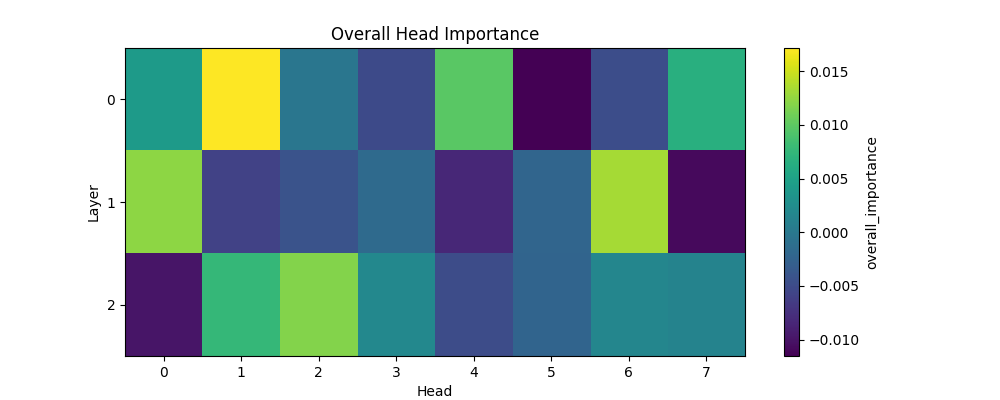

Grafik kaydedildi.


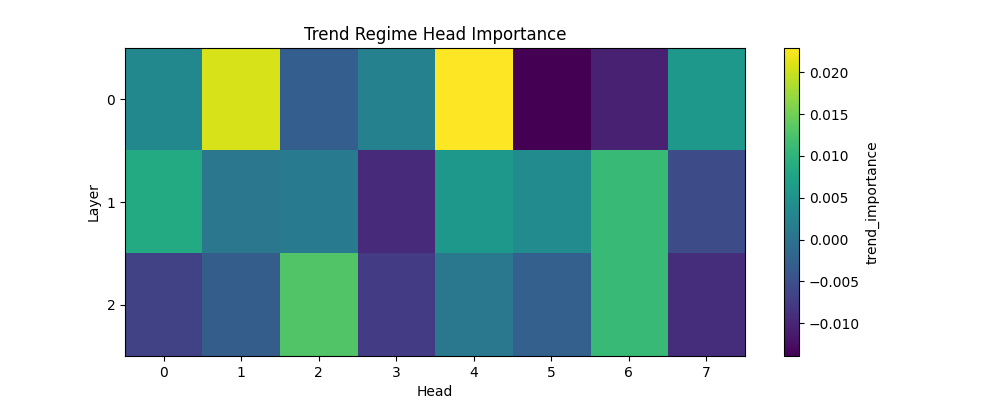

Grafik kaydedildi.


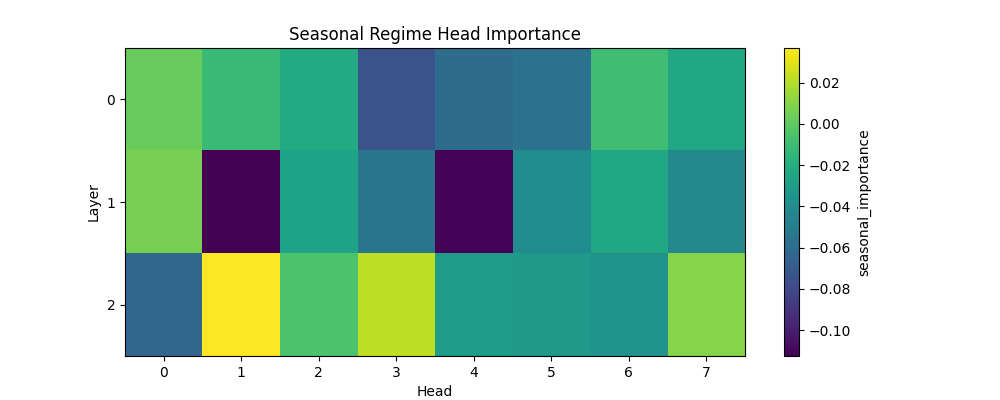

Grafik kaydedildi.


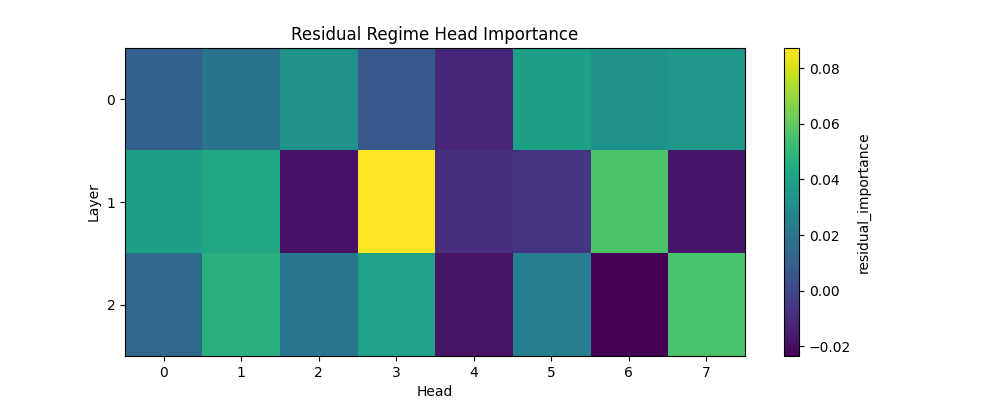

In [73]:
plot_importance_heatmap(
    importance_df,
    "overall_importance",
    "Overall Head Importance"
)

plot_importance_heatmap(
    importance_df,
    "trend_importance",
    "Trend Regime Head Importance"
)

plot_importance_heatmap(
    importance_df,
    "seasonal_importance",
    "Seasonal Regime Head Importance"
)

plot_importance_heatmap(
    importance_df,
    "residual_importance",
    "Residual Regime Head Importance"
)

In [74]:
summary_dir = HEAD_IMPORTANCE_DIR / "summaries"
summary_dir.mkdir(parents=True, exist_ok=True)

# Overall sıralama
overall_ranking = (
    importance_df
    .sort_values("overall_importance", ascending=False)
    .reset_index(drop=True)
)

overall_ranking.to_csv(
    summary_dir / "overall_head_importance_ranking.csv",
    index=False,
)

# Trend sıralama
trend_ranking = (
    importance_df
    .sort_values("trend_importance", ascending=False)
    .reset_index(drop=True)
)

trend_ranking.to_csv(
    summary_dir / "trend_head_importance_ranking.csv",
    index=False,
)

# Seasonal sıralama
seasonal_ranking = (
    importance_df
    .sort_values("seasonal_importance", ascending=False)
    .reset_index(drop=True)
)

seasonal_ranking.to_csv(
    summary_dir / "seasonal_head_importance_ranking.csv",
    index=False,
)

# Residual sıralama
residual_ranking = (
    importance_df
    .sort_values("residual_importance", ascending=False)
    .reset_index(drop=True)
)

residual_ranking.to_csv(
    summary_dir / "residual_head_importance_ranking.csv",
    index=False,
)

print("Ranking dosyaları kaydedildi:")
print(summary_dir)

Ranking dosyaları kaydedildi:
/content/drive/MyDrive/BIL401_Regime_Head_Pruning/head_importance/summaries


In [75]:
# En düşük overall importance'a sahip head'ler
static_pruning_candidates = (
    importance_df
    .sort_values("overall_importance", ascending=True)
    .reset_index(drop=True)
)

display(static_pruning_candidates.head(12))

static_pruning_candidates.to_csv(
    summary_dir / "static_pruning_candidates_by_overall_importance.csv",
    index=False,
)

,layer,head,baseline_overall_mse,masked_overall_mse,overall_importance,baseline_trend_mse,masked_trend_mse,trend_importance,baseline_seasonal_mse,masked_seasonal_mse,seasonal_importance,baseline_residual_mse,masked_residual_mse,residual_importance
0,0,5,0.678066,0.666531,-0.011536,0.67695,0.663047,-0.013904,0.706689,0.649556,-0.057133,0.661419,0.701048,0.039628
1,1,7,0.678066,0.667222,-0.010845,0.67695,0.671467,-0.005483,0.706689,0.664153,-0.042537,0.661419,0.644482,-0.016937
2,2,0,0.678066,0.668174,-0.009892,0.67695,0.670266,-0.006684,0.706689,0.643613,-0.063077,0.661419,0.675717,0.014298
3,1,4,0.678066,0.669715,-0.008351,0.67695,0.682599,0.005648,0.706689,0.595589,-0.111100,0.661419,0.653424,-0.007995
4,1,1,0.678066,0.672244,-0.005822,0.67695,0.677648,0.000697,0.706689,0.594095,-0.112594,0.661419,0.703687,0.042267
5,0,3,0.678066,0.672993,-0.005073,0.67695,0.679229,0.002279,0.706689,0.632469,-0.074220,0.661419,0.668884,0.007465
6,2,4,0.678066,0.673228,-0.004838,0.67695,0.677745,0.000795,0.706689,0.676442,-0.030248,0.661419,0.643762,-0.017657
7,0,6,0.678066,0.673324,-0.004742,0.67695,0.666386,-0.010565,0.706689,0.697650,-0.009039,0.661419,0.694779,0.033360
8,1,2,0.678066,0.673917,-0.004150,0.67695,0.678121,0.001171,0.706689,0.680556,-0.026133,0.661419,0.643523,-0.017896
9,2,5,0.678066,0.675731,-0.002336,0.67695,0.674284,-0.002666,0.706689,0.674060,-0.032629,0.661419,0.685687,0.024267


In [76]:
static_prune_25 = static_pruning_candidates.head(6).copy()
static_keep_25 = importance_df.merge(
    static_prune_25[["layer", "head"]],
    on=["layer", "head"],
    how="left",
    indicator=True,
)

static_keep_25 = static_keep_25[
    static_keep_25["_merge"] == "left_only"
].drop(columns=["_merge"])

display(static_prune_25)

static_prune_25.to_csv(
    summary_dir / "static_prune_25_percent_heads.csv",
    index=False,
)

static_keep_25.to_csv(
    summary_dir / "static_keep_75_percent_heads.csv",
    index=False,
)

,layer,head,baseline_overall_mse,masked_overall_mse,overall_importance,baseline_trend_mse,masked_trend_mse,trend_importance,baseline_seasonal_mse,masked_seasonal_mse,seasonal_importance,baseline_residual_mse,masked_residual_mse,residual_importance
0,0,5,0.678066,0.666531,-0.011536,0.67695,0.663047,-0.013904,0.706689,0.649556,-0.057133,0.661419,0.701048,0.039628
1,1,7,0.678066,0.667222,-0.010845,0.67695,0.671467,-0.005483,0.706689,0.664153,-0.042537,0.661419,0.644482,-0.016937
2,2,0,0.678066,0.668174,-0.009892,0.67695,0.670266,-0.006684,0.706689,0.643613,-0.063077,0.661419,0.675717,0.014298
3,1,4,0.678066,0.669715,-0.008351,0.67695,0.682599,0.005648,0.706689,0.595589,-0.111100,0.661419,0.653424,-0.007995
4,1,1,0.678066,0.672244,-0.005822,0.67695,0.677648,0.000697,0.706689,0.594095,-0.112594,0.661419,0.703687,0.042267
5,0,3,0.678066,0.672993,-0.005073,0.67695,0.679229,0.002279,0.706689,0.632469,-0.074220,0.661419,0.668884,0.007465


In [77]:
def get_top_heads_for_regime(
    importance_df,
    regime,
    keep_ratio=0.5,
):
    importance_col = f"{regime}_importance"

    num_total = len(importance_df)
    num_keep = int(num_total * keep_ratio)

    top_heads = (
        importance_df
        .sort_values(importance_col, ascending=False)
        .head(num_keep)
        .copy()
    )

    return top_heads


dynamic_keep_ratio = 0.5

dynamic_trend_keep = get_top_heads_for_regime(
    importance_df,
    "trend",
    keep_ratio=dynamic_keep_ratio,
)

dynamic_seasonal_keep = get_top_heads_for_regime(
    importance_df,
    "seasonal",
    keep_ratio=dynamic_keep_ratio,
)

dynamic_residual_keep = get_top_heads_for_regime(
    importance_df,
    "residual",
    keep_ratio=dynamic_keep_ratio,
)

display(dynamic_trend_keep[["layer", "head", "trend_importance"]])
display(dynamic_seasonal_keep[["layer", "head", "seasonal_importance"]])
display(dynamic_residual_keep[["layer", "head", "residual_importance"]])

,layer,head,trend_importance
4,0,4,0.022900
1,0,1,0.020611
18,2,2,0.012905
22,2,6,0.011054
14,1,6,0.010993
8,1,0,0.008527
7,0,7,0.005714
12,1,4,0.005648
13,1,5,0.003802
0,0,0,0.003296


,layer,head,seasonal_importance
17,2,1,0.036730
19,2,3,0.022212
23,2,7,0.009473
8,1,0,0.006389
0,0,0,0.002190
18,2,2,-0.005710
6,0,6,-0.009039
1,0,1,-0.010837
2,0,2,-0.021349
7,0,7,-0.023027


,layer,head,residual_importance
11,1,3,0.087188
14,1,6,0.056504
23,2,7,0.055780
17,2,1,0.046922
9,1,1,0.042267
19,2,3,0.040165
5,0,5,0.039628
8,1,0,0.039080
7,0,7,0.035285
6,0,6,0.033360


In [78]:
dynamic_trend_keep.to_csv(
    summary_dir / "dynamic_trend_keep_50_percent_heads.csv",
    index=False,
)

dynamic_seasonal_keep.to_csv(
    summary_dir / "dynamic_seasonal_keep_50_percent_heads.csv",
    index=False,
)

dynamic_residual_keep.to_csv(
    summary_dir / "dynamic_residual_keep_50_percent_heads.csv",
    index=False,
)

In [79]:
importance_df["regime_specialization"] = (
    importance_df[
        [
            "trend_importance",
            "seasonal_importance",
            "residual_importance",
        ]
    ]
    .max(axis=1)
    -
    importance_df[
        [
            "trend_importance",
            "seasonal_importance",
            "residual_importance",
        ]
    ]
    .min(axis=1)
)

specialized_heads = (
    importance_df
    .sort_values("regime_specialization", ascending=False)
    .reset_index(drop=True)
)

display(
    specialized_heads[
        [
            "layer",
            "head",
            "trend_importance",
            "seasonal_importance",
            "residual_importance",
            "regime_specialization",
        ]
    ]
    .head(10)
)

specialized_heads.to_csv(
    summary_dir / "regime_specialized_heads.csv",
    index=False,
)

,layer,head,trend_importance,seasonal_importance,residual_importance,regime_specialization
0,1,1,0.000697,-0.112594,0.042267,0.154861
1,1,3,-0.009314,-0.054581,0.087188,0.141769
2,1,4,0.005648,-0.111100,-0.007995,0.116748
3,0,5,-0.013904,-0.057133,0.039628,0.096761
4,0,4,0.022900,-0.059748,-0.011217,0.082648
5,0,3,0.002279,-0.074220,0.007465,0.081685
6,1,6,0.010993,-0.023151,0.056504,0.079655
7,2,0,-0.006684,-0.063077,0.014298,0.077374
8,2,7,-0.009050,0.009473,0.055780,0.064829
9,0,7,0.005714,-0.023027,0.035285,0.058312
